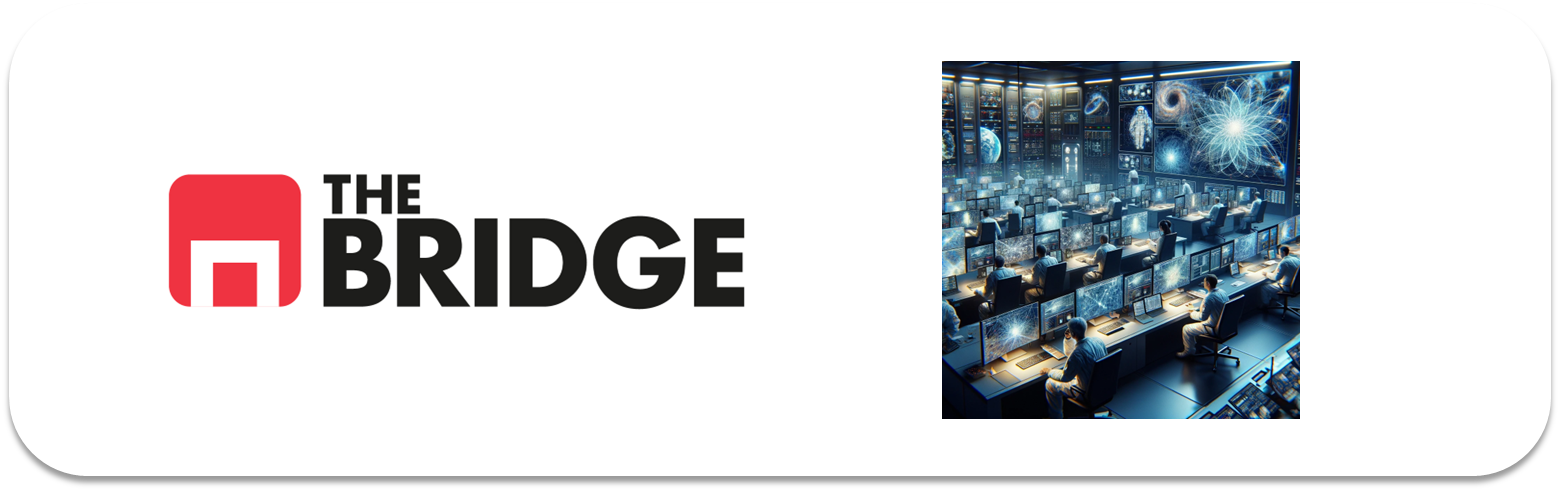

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Semilla para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)
print('Keras version:', keras.__version__)

TensorFlow version: 2.21.0
Keras version: 3.13.2


### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



### Ejercicio 1 — Carga y preparación del dataset

Leemos las imágenes de los 4 directorios de train y del directorio de test.  
La clase (perro/gato) se infiere del **nombre del fichero**: los archivos que contienen `dog` en el nombre son perros (clase 1) y los que contienen `cat` son gatos (clase 0).

In [2]:
IMG_SIZE = (32, 32)          # tamaño
TARGET_SIZE = IMG_SIZE + (3,)  # 32x32x3

TRAIN_DIRS = [
    'data/github_train_0',
    'data/github_train_1',
    'data/github_train_2',   
    'data/github_train_3',
]
TEST_DIR  = 'data/github_test'


def load_images_from_dirs(dirs, img_size=IMG_SIZE):
    """Lee imágenes de una lista de directorios y devuelve X (array) e y (etiquetas).
    La etiqueta se obtiene del nombre de fichero: 'dog' -> 1, 'cat' -> 0.
    """
    X, y, filenames = [], [], []
    if isinstance(dirs, str):
        dirs = [dirs]
    for d in dirs:
        for fname in sorted(os.listdir(d)):
            fpath = os.path.join(d, fname)
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            # Etiqueta por nombre de fichero
            fname_lower = fname.lower()
            if 'dog' in fname_lower:
                label = 1
            elif 'cat' in fname_lower:
                label = 0
            else:
                continue  # imagen sin etiqueta reconocible → saltar
            try:
                img = Image.open(fpath).convert('RGB').resize(img_size)
                X.append(np.array(img))
                y.append(label)
                filenames.append(fname)
            except Exception as e:
                print(f'Error leyendo {fpath}: {e}')
    return np.array(X, dtype='float32'), np.array(y), filenames


# --- TRAIN ---
X_train_full, y_train_full, fnames_train = load_images_from_dirs(TRAIN_DIRS)

# --- TEST ---
X_test, y_test, fnames_test = load_images_from_dirs(TEST_DIR)

print(f'Train → {X_train_full.shape}, etiquetas: {y_train_full.shape}')
print(f'Test  → {X_test.shape},  etiquetas: {y_test.shape}')
print(f'Distribución train  → gatos: {(y_train_full==0).sum()}, perros: {(y_train_full==1).sum()}')
print(f'Distribución test   → gatos: {(y_test==0).sum()},  perros: {(y_test==1).sum()}')

Train → (4000, 32, 32, 3), etiquetas: (4000,)
Test  → (1000, 32, 32, 3),  etiquetas: (1000,)
Distribución train  → gatos: 2000, perros: 2000
Distribución test   → gatos: 500,  perros: 500


In [3]:
# Normalización [0, 1]
X_train_full = X_train_full / 255.0
X_test       = X_test       / 255.0

# Split train / validación (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2, random_state=42, stratify=y_train_full
)

print(f'Train efectivo: {X_train.shape[0]} | Validación: {X_val.shape[0]} | Test: {X_test.shape[0]}')


Train efectivo: 3200 | Validación: 800 | Test: 1000


### Mini-EDA y visualización del dataset

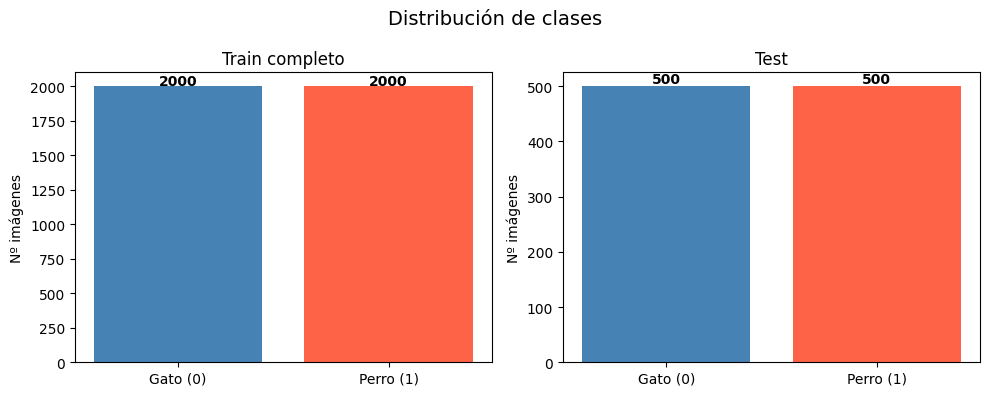

In [4]:
# --- Distribución de clases ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (split, labels, title) in zip(axes, [
        (X_train_full, y_train_full, 'Train completo'),
        (X_test,       y_test,       'Test')
    ]):
    clases, counts = np.unique(labels, return_counts=True)
    ax.bar(['Gato (0)', 'Perro (1)'], counts, color=['steelblue', 'tomato'])
    ax.set_title(title)
    ax.set_ylabel('Nº imágenes')
    for i, c in enumerate(counts):
        ax.text(i, c + 5, str(c), ha='center', fontweight='bold')
plt.suptitle('Distribución de clases', fontsize=14)
plt.tight_layout()
plt.show()

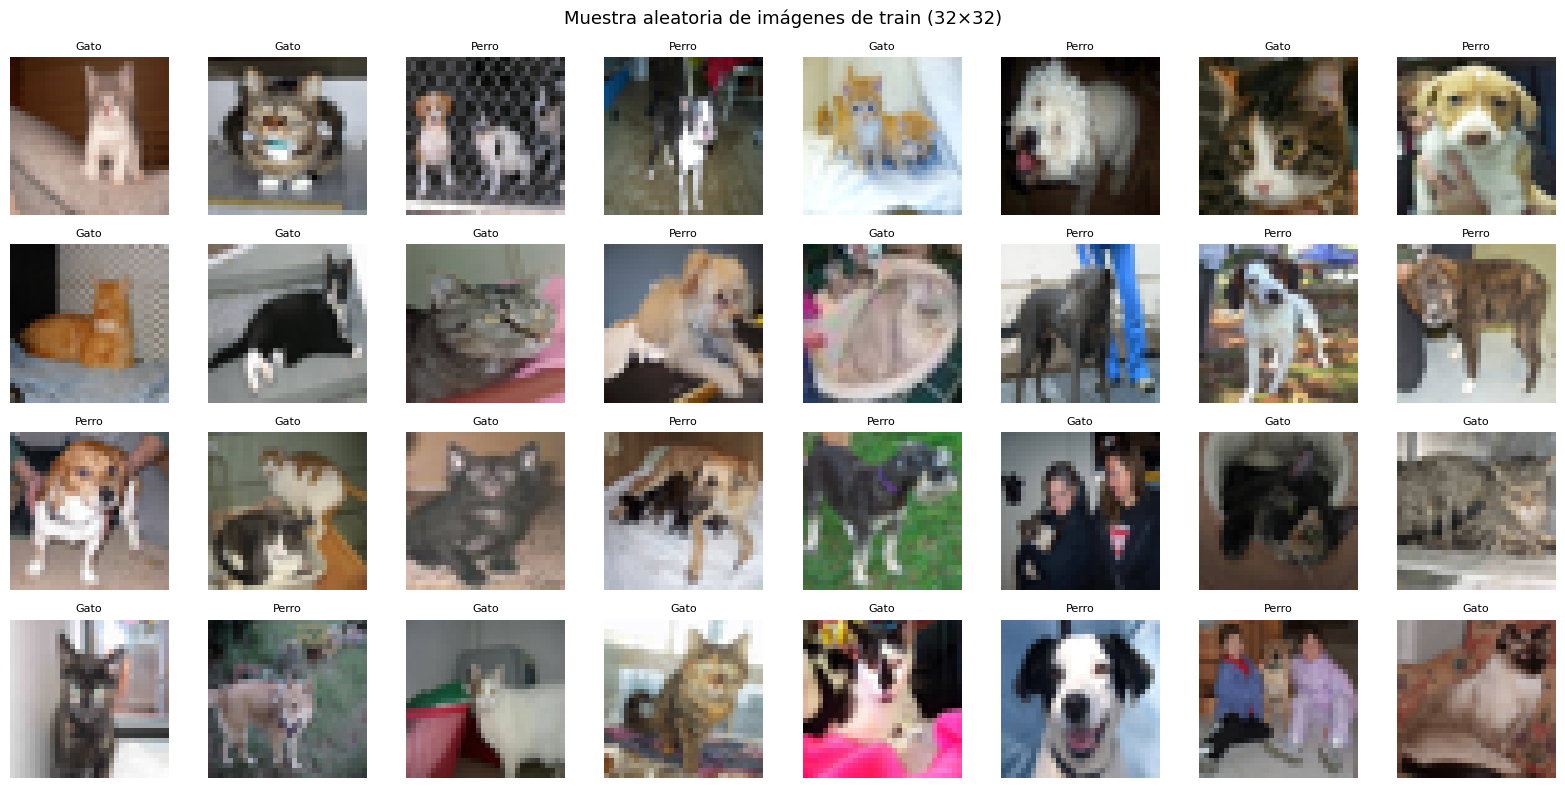

In [5]:
# --- Muestras aleatorias ---
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
label_names = {0: 'Gato', 1: 'Perro'}
indices = np.random.choice(len(X_train), 32, replace=False)
for ax, idx in zip(axes.ravel(), indices):
    ax.imshow(X_train[idx])
    ax.set_title(label_names[y_train[idx]], fontsize=8)
    ax.axis('off')
plt.suptitle('Muestra aleatoria de imágenes de train (32×32)', fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
# --- Estadísticas básicas de los píxeles ---
print('=== Mini-EDA de píxeles (train) ===')
for canal, nombre in zip(range(3), ['Rojo', 'Verde', 'Azul']):
    vals = X_train[:, :, :, canal].ravel()
    print(f'  Canal {nombre}: media={vals.mean():.3f}  std={vals.std():.3f}  '
          f'min={vals.min():.3f}  max={vals.max():.3f}')

=== Mini-EDA de píxeles (train) ===
  Canal Rojo: media=0.489  std=0.248  min=0.000  max=1.000
  Canal Verde: media=0.455  std=0.241  min=0.000  max=1.000
  Canal Azul: media=0.417  std=0.245  min=0.000  max=1.000


### Ejercicio 2 — Construcción del modelo CNN

Arquitectura con **dos bloques Convolución → Pooling** seguidos de capas densas.

In [7]:
def build_cnn(input_shape=(32, 32, 3)):
    model = models.Sequential([
        # --- Bloque 1 ---
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        # --- Bloque 2 ---
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        # --- Bloque 3 (extra, mejora el accuracy) ---
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        # --- Cabeza clasificadora ---
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')  # clasificación binaria
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


model = build_cnn()
model.summary()

C:\Users\kelly\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 666,145 (2.54 MB)

 Trainable params: 665,185 (2.54 MB)

 Non-trainable params: 960 (3.75 KB)

### Ejercicio 3 — Entrenamiento con EarlyStopping

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,           # ¡la paciencia que tengamos! :-)
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.5734 - loss: 0.9170 - val_accuracy: 0.5000 - val_loss: 0.7217
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 583ms/step - accuracy: 0.6272 - loss: 0.7784 - val_accuracy: 0.5000 - val_loss: 0.6990
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 462ms/step - accuracy: 0.6531 - loss: 0.6878 - val_accuracy: 0.5000 - val_loss: 0.9333
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 485ms/step - accuracy: 0.6794 - loss: 0.6366 - val_accuracy: 0.5000 - val_loss: 1.0137
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 588ms/step - accuracy: 0.6862 - loss: 0.6183 - val_accuracy: 0.5125 - val_loss: 0.8316
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 36s 485ms/step - accuracy: 0.7131 - loss: 0.5650 - val_accuracy: 0.5000 - val_loss: 1.3086
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 478ms/step - accuracy: 0.7347 - loss: 0.5367 - val_accuracy: 0.5300 - val_loss: 0.8980
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.7416 - loss: 0.5237 - val_

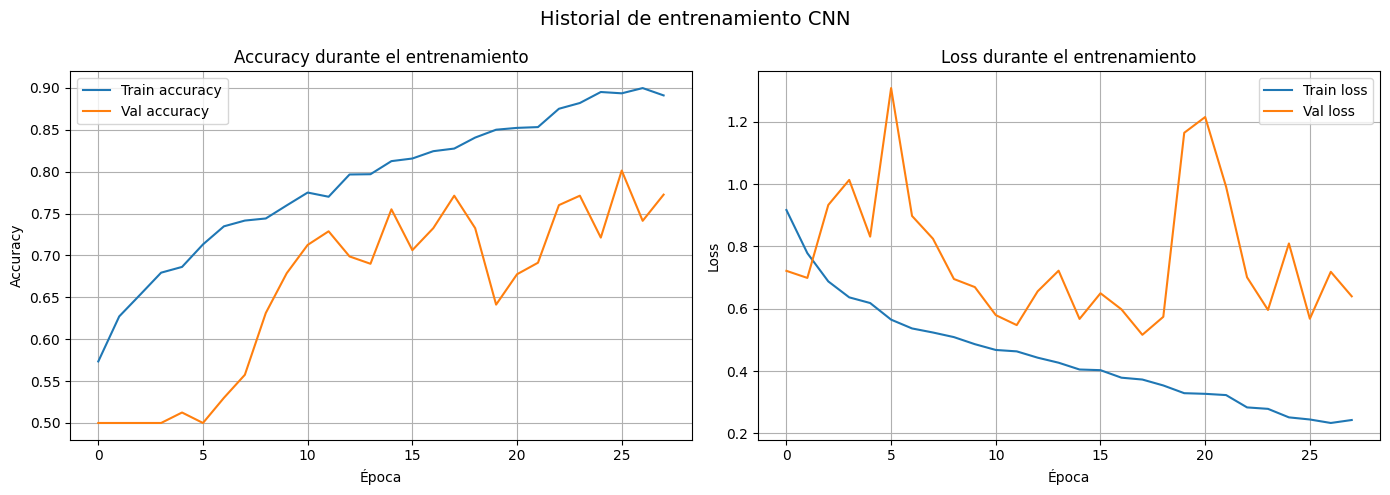

Figura guardada: historial_entrenamiento.png


In [9]:
# --- Historial de entrenamiento ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val accuracy')
axes[0].set_title('Accuracy durante el entrenamiento')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'],     label='Train loss')
axes[1].plot(history.history['val_loss'], label='Val loss')
axes[1].set_title('Loss durante el entrenamiento')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Historial de entrenamiento CNN', fontsize=14)
plt.tight_layout()
plt.savefig('historial_entrenamiento.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada: historial_entrenamiento.png')

### Ejercicio 4 — Evaluación, reporte de clasificación y matriz de confusión

In [10]:
# Probabilidades y etiquetas predichas en test
y_prob = model.predict(X_test, verbose=0).ravel()   # P(perro)
y_pred = (y_prob >= 0.5).astype(int)

# Métricas generales
loss_test, acc_test = model.evaluate(X_test, y_test, verbose=0)
print(f'\nTest Loss    : {loss_test:.4f}')
print(f'Test Accuracy: {acc_test:.4f}  ({acc_test*100:.2f}%)')


Test Loss    : 0.5068
Test Accuracy: 0.7900  (79.00%)


In [11]:
# Reporte de clasificación
print('\n=== Reporte de Clasificación ===')
print(classification_report(y_test, y_pred, target_names=['Gato (0)', 'Perro (1)']))


=== Reporte de Clasificación ===
              precision    recall  f1-score   support

    Gato (0)       0.80      0.78      0.79       500
   Perro (1)       0.78      0.80      0.79       500

    accuracy                           0.79      1000
   macro avg       0.79      0.79      0.79      1000
weighted avg       0.79      0.79      0.79      1000



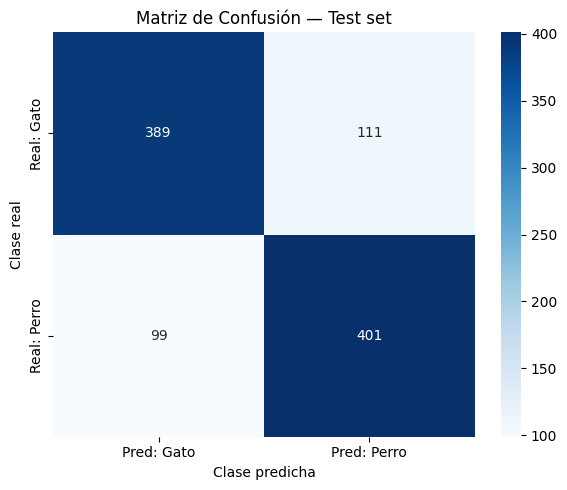

Figura guardada: matriz_confusion.png


In [12]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Pred: Gato', 'Pred: Perro'],
    yticklabels=['Real: Gato', 'Real: Perro'],
    ax=ax
)
ax.set_title('Matriz de Confusión — Test set')
ax.set_ylabel('Clase real')
ax.set_xlabel('Clase predicha')
plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada: matriz_confusion.png')